In [3]:
#To implement Neural Style Transfer (NST) using Deep Learning techniques to generate artistic images by combining the content of one image with the style of another image.

In [4]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.applications import VGG19
from tensorflow.keras.applications.vgg19 import preprocess_input

In [5]:
# Step 1: Load Images
# -----------------------------------
def load_image(path):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3)
    img = tf.image.convert_image_dtype(img, tf.float32)
    img = tf.image.resize(img, (256, 256))
    img = img[tf.newaxis, :]
    return img

print("Downloading images...")
content_path = tf.keras.utils.get_file(
    'content.jpg',
    'https://storage.googleapis.com/download.tensorflow.org/example_images/YellowLabradorLooking_new.jpg'
)

style_path = tf.keras.utils.get_file(
    'style.jpg',
    'https://storage.googleapis.com/download.tensorflow.org/example_images/Vassily_Kandinsky%2C_1913_-_Composition_7.jpg'
)

content_image = load_image(content_path)
style_image = load_image(style_path)

83281/83281 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
195196/195196 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step


In [6]:
# Step 2: Load VGG19 Model
# -----------------------------------
vgg = VGG19(include_top=False, weights='imagenet')
vgg.trainable = False

# Select layers
content_layer = 'block5_conv2'
style_layers = ['block1_conv1', 'block2_conv1', 'block3_conv1']

outputs = [vgg.get_layer(name).output for name in style_layers + [content_layer]]
model = tf.keras.Model(inputs=vgg.input, outputs=outputs)

In [7]:
# Step 3: Feature Extraction
# -----------------------------------
def get_features(image):
    image = image * 255.0
    image = preprocess_input(image)
    outputs = model(image)
    
    style_features = outputs[:-1]
    content_feature = outputs[-1]
    
    return style_features, content_feature

# Gram Matrix (for style)
def gram_matrix(x):
    x = tf.reshape(x, (-1, x.shape[-1]))
    return tf.matmul(x, x, transpose_a=True)

# Targets
style_targets, _ = get_features(style_image)
_, content_target = get_features(content_image)

In [8]:
# Step 4: Loss Function
# -----------------------------------
def compute_loss(image):
    style_outputs, content_output = get_features(image)
    
    # Content loss
    content_loss = tf.reduce_mean((content_output - content_target) ** 2)
    
    # Style loss
    style_loss = 0
    for s_out, s_tar in zip(style_outputs, style_targets):
        gram_s = gram_matrix(s_out)
        gram_t = gram_matrix(s_tar)
        style_loss += tf.reduce_mean((gram_s - gram_t) ** 2)
    
    total_loss = content_loss * 1e4 + style_loss * 1e-2
    return total_loss

In [9]:
# Step 5: Optimization
# -----------------------------------
generated_image = tf.Variable(content_image)
optimizer = tf.optimizers.Adam(learning_rate=0.02)

@tf.function
def train_step():
    with tf.GradientTape() as tape:
        loss = compute_loss(generated_image)
    
    grad = tape.gradient(loss, generated_image)
    optimizer.apply_gradients([(grad, generated_image)])
    generated_image.assign(tf.clip_by_value(generated_image, 0.0, 1.0))

In [10]:
# Step 6: Training Loop
# -----------------------------------
print("Starting Style Transfer...")
epochs = 5

for i in range(epochs):
    train_step()
    print("Epoch", i+1, "completed")

Starting Style Transfer...
Epoch 1 completed
Epoch 2 completed
Epoch 3 completed
Epoch 4 completed
Epoch 5 completed


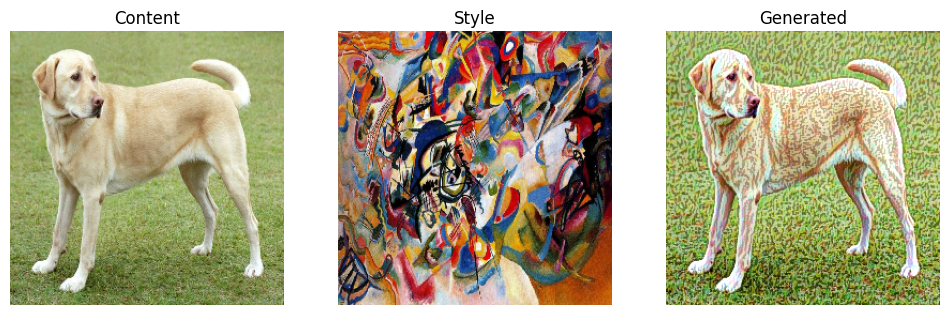

Neural Style Transfer completed successfully.


In [11]:
# Step 7: Display Results
# -----------------------------------
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("Content")
plt.imshow(tf.squeeze(content_image))
plt.axis('off')

plt.subplot(1,3,2)
plt.title("Style")
plt.imshow(tf.squeeze(style_image))
plt.axis('off')

plt.subplot(1,3,3)
plt.title("Generated")
plt.imshow(tf.squeeze(generated_image))
plt.axis('off')

plt.show()

print("Neural Style Transfer completed successfully.")